📊 ANÁLISIS DE CORRELACIÓN - PAIRPLOT

💡 ESTRATEGIA DE VISUALIZACIÓN:
   ✅ Variables seleccionadas: Solo numéricas continuas/discretas
   ✅ Exclusión de variables dummy: Evita saturación visual
   ✅ Configuración corner=True: Elimina duplicación de información
   ✅ Líneas de regresión (kind='reg'): Evalúa relaciones lineales
   ✅ Transparencia (alpha): Maneja overplotting en datasets grandes

📋 Variables incluidas en el Pairplot: 5
   1. log_price
   2. accommodates
   3. bathrooms
   4. bedrooms
   5. number_of_reviews

📊 Información del subset:
   Filas: 66,438
   Columnas: 5
   Valores nulos: 0

📊 Estadísticas descriptivas:


,count,mean,std,min,25%,50%,75%,max
log_price,66438.0,4.676507,0.597925,3.044522,4.248495,4.60517,5.075174,6.309918
accommodates,66438.0,2.675652,1.341635,1.000000,2.000000,2.00000,4.000000,7.000000
bathrooms,66438.0,1.142170,0.402541,0.000000,1.000000,1.00000,1.000000,8.000000
bedrooms,66438.0,1.099250,0.589449,0.000000,1.000000,1.00000,1.000000,10.000000
number_of_reviews,66438.0,21.061757,38.422801,0.000000,1.000000,6.00000,23.000000,605.000000



🎨 Generando Pairplot...
   ⏳ Esto puede tomar varios segundos debido al tamaño del dataset...
   💾 Guardado: Visualizaciones/proyectoFinal/08_pairplot_correlaciones.png


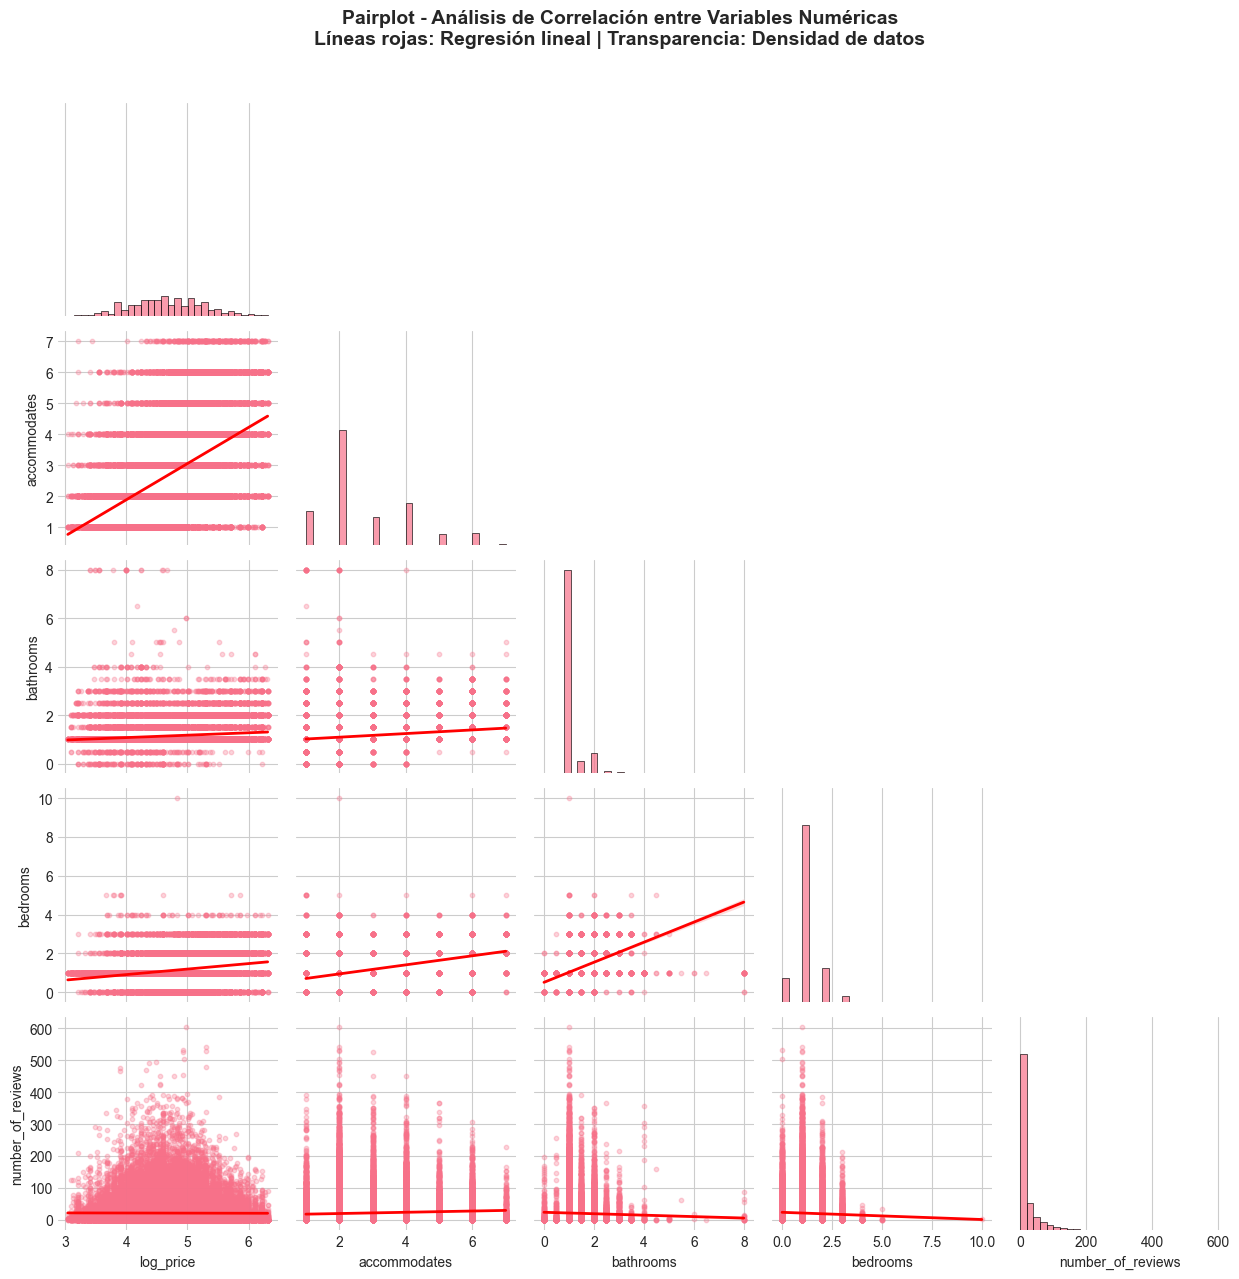


✅ Pairplot generado exitosamente

📊 MATRIZ DE CORRELACIÓN

📋 Matriz de correlación completa:


,log_price,accommodates,bathrooms,bedrooms,number_of_reviews
log_price,1.000,0.520,0.148,0.288,-0.006
accommodates,0.520,1.000,0.250,0.532,0.068
bathrooms,0.148,0.250,1.000,0.353,-0.024
bedrooms,0.288,0.532,0.353,1.000,-0.035
number_of_reviews,-0.006,0.068,-0.024,-0.035,1.000


   💾 Guardado: Visualizaciones/proyectoFinal/09_matriz_correlacion_corner.png


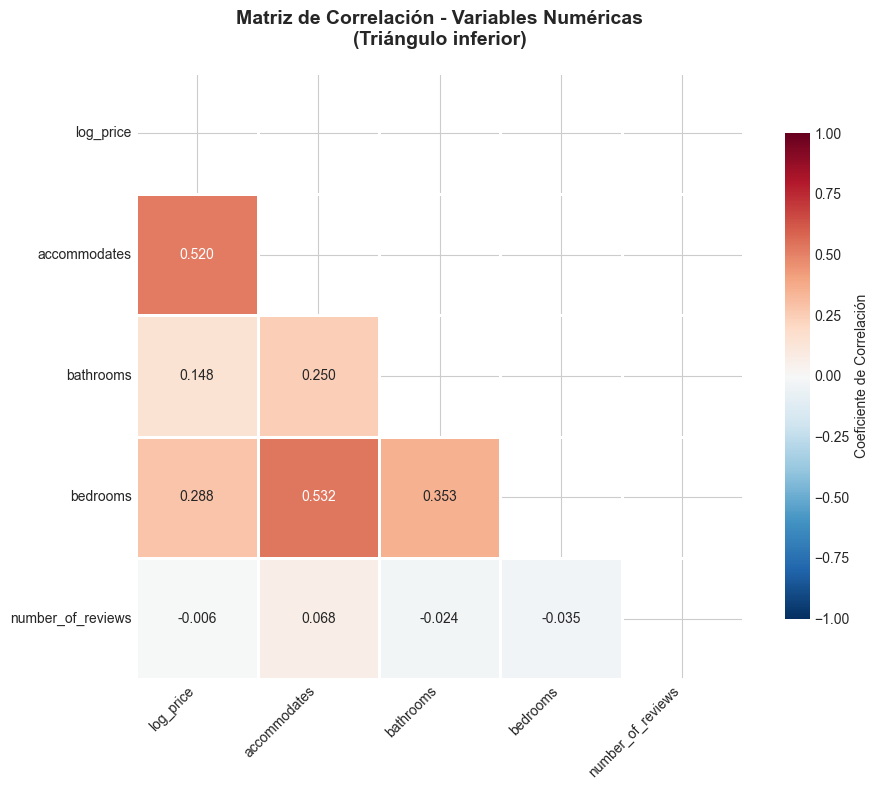


🎯 ANÁLISIS DE CORRELACIONES CON log_price

📊 Correlaciones ordenadas (de mayor a menor):
   1. accommodates              +0.5201  🟡 Moderada
   2. bedrooms                  +0.2882  🟢 Débil
   3. bathrooms                 +0.1478  ⚪ Muy débil
   4. number_of_reviews         -0.0057  ⚪ Muy débil
   💾 Guardado: Visualizaciones/proyectoFinal/10_correlaciones_log_price_barras.png


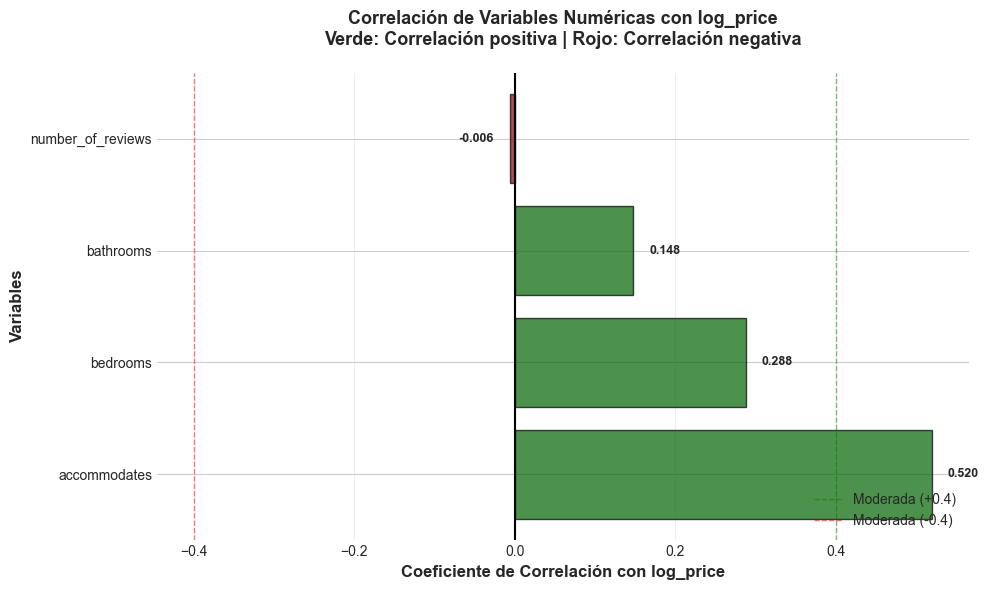


💡 INTERPRETACIÓN Y RECOMENDACIONES

✅ Variables con correlación moderada o fuerte (|r| ≥ 0.3):
   • accommodates: 0.5201

   💡 Estas variables son candidatas fuertes para el modelo de regresión

⚠️  Variables con correlación muy débil (|r| < 0.2):
   • bathrooms: 0.1478
   • number_of_reviews: -0.0057

   💡 Considerar excluir estas variables del modelo final

🔍 ANÁLISIS DE MULTICOLINEALIDAD ENTRE PREDICTORES

⚠️  Pares de predictores con correlación |r| > 0.5:


,Variable 1,Variable 2,Correlación
0,accommodates,bedrooms,0.532141



   💡 Alta correlación entre predictores puede causar multicolinealidad
      Considerar eliminar una variable de cada par en el modelo final

✅ Análisis de correlación completado exitosamente


In [32]:
# ====================================================================
# ============================================
# 4. ANÁLISIS DE CORRELACIÓN - PAIRPLOT
# ============================================

print("="*70)
print("📊 ANÁLISIS DE CORRELACIÓN - PAIRPLOT")
print("="*70)

print("\n💡 ESTRATEGIA DE VISUALIZACIÓN:")
print("="*70)
print("   ✅ Variables seleccionadas: Solo numéricas continuas/discretas")
print("   ✅ Exclusión de variables dummy: Evita saturación visual")
print("   ✅ Configuración corner=True: Elimina duplicación de información")
print("   ✅ Líneas de regresión (kind='reg'): Evalúa relaciones lineales")
print("   ✅ Transparencia (alpha): Maneja overplotting en datasets grandes")

# Seleccionar variables numéricas para el pairplot
# Excluir variables dummy (que empiezan con 'room_type_', 'property_type_', etc.)
variables_pairplot = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'number_of_reviews']

# Verificar que todas las variables existen
variables_disponibles = [var for var in variables_pairplot if var in df_limpio.columns]

print(f"\n📋 Variables incluidas en el Pairplot: {len(variables_disponibles)}")
for i, var in enumerate(variables_disponibles, 1):
    print(f"   {i}. {var}")

if len(variables_disponibles) >= 2:
    # Crear subset de datos
    df_pairplot = df_limpio[variables_disponibles].copy()
    
    # Información del subset
    print(f"\n📊 Información del subset:")
    print(f"   Filas: {df_pairplot.shape[0]:,}")
    print(f"   Columnas: {df_pairplot.shape[1]}")
    print(f"   Valores nulos: {df_pairplot.isnull().sum().sum()}")
    
    # Eliminar valores nulos si existen
    if df_pairplot.isnull().sum().sum() > 0:
        filas_antes = len(df_pairplot)
        df_pairplot = df_pairplot.dropna()
        filas_despues = len(df_pairplot)
        print(f"   ⚠️  Eliminadas {filas_antes - filas_despues:,} filas con valores nulos")
    
    # Estadísticas descriptivas del subset
    print(f"\n📊 Estadísticas descriptivas:")
    display(df_pairplot.describe().T)
    
    # Generar Pairplot
    print(f"\n🎨 Generando Pairplot...")
    print(f"   ⏳ Esto puede tomar varios segundos debido al tamaño del dataset...")
    
    # Configuración del pairplot
    sns.set_style("whitegrid")
    
    pairplot = sns.pairplot(
        df_pairplot,
        kind='reg',              # Incluye líneas de regresión
        diag_kind='hist',        # Histogramas en la diagonal
        corner=True,             # Solo muestra el triángulo inferior
        plot_kws={
            'scatter_kws': {'alpha': 0.3, 's': 10},  # Transparencia y tamaño de puntos
            'line_kws': {'color': 'red', 'linewidth': 2}  # Línea de regresión
        },
        diag_kws={
            'bins': 30,          # Número de bins en histogramas
            'edgecolor': 'black',
            'alpha': 0.7
        },
        height=2.5,              # Altura de cada subplot
        aspect=1                 # Aspecto cuadrado
    )
    
    # Título general
    pairplot.fig.suptitle(
        'Pairplot - Análisis de Correlación entre Variables Numéricas\n' +
        'Líneas rojas: Regresión lineal | Transparencia: Densidad de datos',
        y=1.02,
        fontsize=14,
        fontweight='bold'
    )
    
    plt.tight_layout()
    guardar_grafico('08_pairplot_correlaciones.png', dpi=300)
    plt.show()
    
    print(f"\n✅ Pairplot generado exitosamente")
    
    # Análisis de correlaciones
    print("\n" + "="*70)
    print("📊 MATRIZ DE CORRELACIÓN")
    print("="*70)
    
    # Calcular matriz de correlación
    correlacion_matriz = df_pairplot.corr()
    
    # Mostrar matriz completa
    print("\n📋 Matriz de correlación completa:")
    display(correlacion_matriz.round(3))
    
    # Visualización de la matriz de correlación
    plt.figure(figsize=(10, 8))
    
    # Crear máscara para el triángulo superior (corner=True)
    mask = np.triu(np.ones_like(correlacion_matriz, dtype=bool))
    
    sns.heatmap(
        correlacion_matriz,
        mask=mask,
        annot=True,
        fmt='.3f',
        cmap='RdBu_r',
        center=0,
        square=True,
        linewidths=1,
        cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación"},
        vmin=-1,
        vmax=1
    )
    
    plt.title('Matriz de Correlación - Variables Numéricas\n(Triángulo inferior)', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    guardar_grafico('09_matriz_correlacion_corner.png')
    plt.show()
    
    # Análisis detallado de correlaciones con log_price
    print("\n" + "="*70)
    print("🎯 ANÁLISIS DE CORRELACIONES CON log_price")
    print("="*70)
    
    correlaciones_precio = correlacion_matriz['log_price'].drop('log_price').sort_values(ascending=False)
    
    print("\n📊 Correlaciones ordenadas (de mayor a menor):")
    for i, (var, corr) in enumerate(correlaciones_precio.items(), 1):
        # Interpretación de la fuerza de correlación
        if abs(corr) >= 0.7:
            fuerza = "🔴 Fuerte"
        elif abs(corr) >= 0.4:
            fuerza = "🟡 Moderada"
        elif abs(corr) >= 0.2:
            fuerza = "🟢 Débil"
        else:
            fuerza = "⚪ Muy débil"
        
        signo = "+" if corr > 0 else "-"
        print(f"   {i}. {var:<25} {signo}{abs(corr):.4f}  {fuerza}")
    
    # Visualización de correlaciones con log_price
    plt.figure(figsize=(10, 6))
    
    colors = ['darkgreen' if x > 0 else 'darkred' for x in correlaciones_precio]
    bars = plt.barh(correlaciones_precio.index, correlaciones_precio.values, 
                    color=colors, alpha=0.7, edgecolor='black')
    
    plt.xlabel('Coeficiente de Correlación con log_price', fontsize=12, fontweight='bold')
    plt.ylabel('Variables', fontsize=12, fontweight='bold')
    plt.title('Correlación de Variables Numéricas con log_price\n' +
              'Verde: Correlación positiva | Rojo: Correlación negativa',
              fontsize=13, fontweight='bold', pad=20)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    plt.axvline(x=0.4, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Moderada (+0.4)')
    plt.axvline(x=-0.4, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Moderada (-0.4)')
    plt.grid(True, alpha=0.3, axis='x')
    plt.legend(loc='lower right')
    
    # Añadir valores en las barras
    for i, (bar, val) in enumerate(zip(bars, correlaciones_precio.values)):
        plt.text(val + (0.02 if val > 0 else -0.02), i, f'{val:.3f}',
                va='center', ha='left' if val > 0 else 'right',
                fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    guardar_grafico('10_correlaciones_log_price_barras.png')
    plt.show()
    
    # Interpretación y recomendaciones
    print("\n" + "="*70)
    print("💡 INTERPRETACIÓN Y RECOMENDACIONES")
    print("="*70)
    
    # Identificar mejores predictores
    mejores_predictores = correlaciones_precio[abs(correlaciones_precio) >= 0.3]
    
    if len(mejores_predictores) > 0:
        print(f"\n✅ Variables con correlación moderada o fuerte (|r| ≥ 0.3):")
        for var, corr in mejores_predictores.items():
            print(f"   • {var}: {corr:.4f}")
        print("\n   💡 Estas variables son candidatas fuertes para el modelo de regresión")
    else:
        print("\n⚠️  No se encontraron variables con correlación moderada o fuerte")
    
    # Identificar predictores débiles
    predictores_debiles = correlaciones_precio[abs(correlaciones_precio) < 0.2]
    
    if len(predictores_debiles) > 0:
        print(f"\n⚠️  Variables con correlación muy débil (|r| < 0.2):")
        for var, corr in predictores_debiles.items():
            print(f"   • {var}: {corr:.4f}")
        print("\n   💡 Considerar excluir estas variables del modelo final")
    
    # Análisis de multicolinealidad entre predictores
    print("\n" + "="*70)
    print("🔍 ANÁLISIS DE MULTICOLINEALIDAD ENTRE PREDICTORES")
    print("="*70)
    
    # Buscar pares con alta correlación (excluyendo log_price)
    vars_sin_precio = [v for v in variables_disponibles if v != 'log_price']
    corr_predictores = df_pairplot[vars_sin_precio].corr()
    
    pares_alta_corr = []
    for i in range(len(corr_predictores.columns)):
        for j in range(i+1, len(corr_predictores.columns)):
            corr_val = corr_predictores.iloc[i, j]
            if abs(corr_val) > 0.5:
                pares_alta_corr.append({
                    'Variable 1': corr_predictores.columns[i],
                    'Variable 2': corr_predictores.columns[j],
                    'Correlación': corr_val
                })
    
    if pares_alta_corr:
        df_pares = pd.DataFrame(pares_alta_corr).sort_values('Correlación', 
                                                              key=abs, 
                                                              ascending=False)
        print(f"\n⚠️  Pares de predictores con correlación |r| > 0.5:")
        display(df_pares)
        print("\n   💡 Alta correlación entre predictores puede causar multicolinealidad")
        print("      Considerar eliminar una variable de cada par en el modelo final")
    else:
        print("\n✅ No se detectó multicolinealidad significativa entre predictores")
    
    print("\n✅ Análisis de correlación completado exitosamente")
    
else:
    print(f"\n❌ Error: Se necesitan al menos 2 variables para generar el pairplot")
    print(f"   Variables disponibles: {len(variables_disponibles)}")
